# Determining Which Prepaid Plan Brings in More Revenue: Surf vs Ultimate

**Project goal**: Analyze client behavior in 2018 and determine which of Megaline’s two prepaid plans (Surf or Ultimate) generated more revenue.

In [8]:
# Initialization – loading libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

# Loading the data files
plans    = pd.read_csv('/datasets/megaline_plans.csv')
users    = pd.read_csv('/datasets/megaline_users.csv')
calls    = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')

## Step 1: Prepare the data

In [9]:
# Convert date columns
users['reg_date']   = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')
calls['call_date']     = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Megaline rounds every individual call up to the next full minute
calls['duration_rounded'] = np.ceil(calls['duration']).astype(int)

# Extract month for aggregation
calls['month']    = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

In [10]:
# Monthly usage per user
calls_monthly = calls.groupby(['user_id','month']).agg(
    calls_made = ('id','count'),
    minutes_used = ('duration_rounded','sum')
).reset_index()

messages_monthly = messages.groupby(['user_id','month']).size().rename('messages_sent').reset_index(name='messages_sent')

internet_monthly = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index()
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024)   # total per month rounded UP

# Combine everything
df = calls_monthly.merge(messages_monthly, on=['user_id','month'], how='outer')
df = df.merge(internet_monthly[['user_id','month','gb_used']], on=['user_id','month'], how='outer')

# Fill zeros for months with no activity
df[['calls_made','minutes_used','messages_sent','gb_used']] = df[['calls_made','minutes_used','messages_sent','gb_used']].fillna(0)

# Add user plan and city
df = df.merge(users[['user_id','plan','city']], on='user_id')
df = df.merge(plans, left_on='plan', right_on='plan_name')

In [11]:
# Revenue calculation (exact Megaline rules)
def calculate_revenue(row):
    minutes_over  = max(0, row['minutes_used'] - row['minutes_included'])
    messages_over = max(0, row['messages_sent'] - row['messages_included'])
    gb_over       = max(0, row['gb_used'] - row['mb_per_month_included']/1024)
    
    revenue = (row['usd_monthly_pay'] +
               minutes_over  * row['usd_per_minute'] +
               messages_over * row['usd_per_message'] +
               gb_over       * row['usd_per_gb'])
    return revenue

df['revenue'] = df.apply(calculate_revenue, axis=1)
display(df.head())

,user_id,month,calls_made,minutes_used,messages_sent,gb_used,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,revenue
0,1000,12,16.0,124.0,11.0,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,70.0
1,1006,11,2.0,10.0,15.0,3.0,ultimate,"San Francisco-Oakland-Berkeley, CA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,70.0
2,1006,12,9.0,59.0,139.0,32.0,ultimate,"San Francisco-Oakland-Berkeley, CA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,84.0
3,1008,10,71.0,476.0,21.0,17.0,ultimate,"Orlando-Kissimmee-Sanford, FL MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,70.0
4,1008,11,63.0,446.0,37.0,24.0,ultimate,"Orlando-Kissimmee-Sanford, FL MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,70.0


## Step 2: Analyze the data – customer behavior

In [12]:
surf    = df[df['plan'] == 'surf']
ultimate = df[df['plan'] == 'ultimate']

print("Surf plan – descriptive statistics")
display(surf[['minutes_used','messages_sent','gb_used','revenue']].describe())

print("Ultimate plan – descriptive statistics")
display(ultimate[['minutes_used','messages_sent','gb_used','revenue']].describe())

Surf plan – descriptive statistics


,minutes_used,messages_sent,gb_used,revenue
count,1573.000000,1573.000000,1573.000000,1573.000000
mean,428.749523,31.159568,16.670693,60.706408
std,234.453150,33.566717,7.847522,55.388042
min,0.000000,0.000000,0.000000,20.000000
25%,272.000000,3.000000,12.000000,20.000000
50%,425.000000,24.000000,17.000000,40.360000
75%,576.000000,47.000000,21.000000,80.360000
max,1510.000000,266.000000,70.000000,590.370000


Ultimate plan – descriptive statistics


,minutes_used,messages_sent,gb_used,revenue
count,720.000000,720.000000,720.000000,720.000000
mean,430.450000,37.551389,17.306944,72.313889
std,240.508762,34.767179,7.670108,11.395108
min,0.000000,0.000000,0.000000,70.000000
25%,260.000000,7.000000,13.000000,70.000000
50%,424.000000,30.000000,17.000000,70.000000
75%,565.250000,61.000000,21.000000,70.000000
max,1369.000000,166.000000,46.000000,182.000000


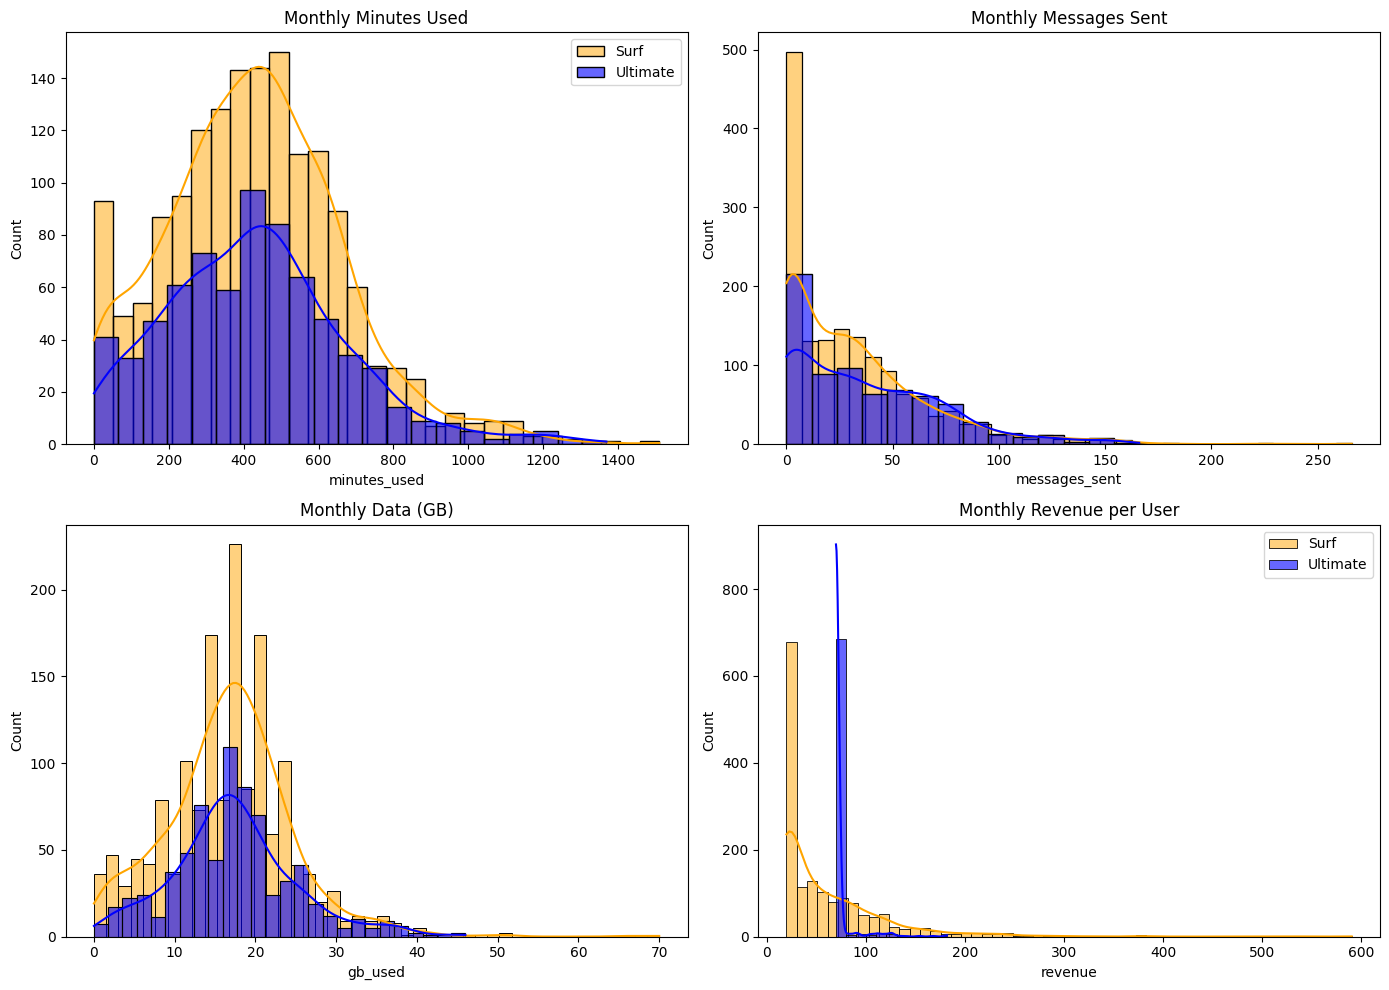

In [13]:
# Histograms
fig, ax = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(surf['minutes_used'],    kde=True, color='orange', label='Surf',    ax=ax[0,0])
sns.histplot(ultimate['minutes_used'],kde=True, color='blue',   alpha=0.6, label='Ultimate', ax=ax[0,0])
ax[0,0].set_title('Monthly Minutes Used'); ax[0,0].legend()

sns.histplot(surf['messages_sent'],    kde=True, color='orange', ax=ax[0,1])
sns.histplot(ultimate['messages_sent'],kde=True, color='blue',   alpha=0.6, ax=ax[0,1])
ax[0,1].set_title('Monthly Messages Sent')

sns.histplot(surf['gb_used'],    kde=True, color='orange', ax=ax[1,0])
sns.histplot(ultimate['gb_used'],kde=True, color='blue',   alpha=0.6, ax=ax[1,0])
ax[1,0].set_title('Monthly Data (GB)')

sns.histplot(surf['revenue'],    kde=True, color='orange', label='Surf',    ax=ax[1,1])
sns.histplot(ultimate['revenue'],kde=True, color='blue',   alpha=0.6, label='Ultimate', ax=ax[1,1])
ax[1,1].set_title('Monthly Revenue per User'); ax[1,1].legend()

plt.tight_layout()
plt.show()

## Step 3: Test statistical hypotheses

In [14]:
alpha = 0.05

# Hypothesis 1: average revenue from Surf and Ultimate users differs
print("Hypothesis 1 – average revenue differs between plans")
result1 = st.ttest_ind(surf['revenue'], ultimate['revenue'], equal_var=False)
print(f"p-value = {result1.pvalue:.2e}")
if result1.pvalue < alpha:
    print("→ Reject H₀: average revenue from the two plans is statistically different\n")
else:
    print("→ Fail to reject H₀\n")

# Hypothesis 2: average revenue in NY-NJ area differs from other regions
df['is_ny_nj'] = df['city'].str.contains('NY-NJ', case=False)
ny_nj   = df[df['is_ny_nj']]['revenue']
others  = df[~df['is_ny_nj']]['revenue']

print("Hypothesis 2 – average revenue NY-NJ vs other regions")
result2 = st.ttest_ind(ny_nj, others, equal_var=False)
print(f"p-value = {result2.pvalue:.2e}")
if result2.pvalue < alpha:
    print("→ Reject H₀: average revenue in NY-NJ area differs from other regions")
else:
    print("→ Fail to reject H₀")

Hypothesis 1 – average revenue differs between plans
p-value = 3.17e-15
→ Reject H₀: average revenue from the two plans is statistically different

Hypothesis 2 – average revenue NY-NJ vs other regions
p-value = 3.35e-02
→ Reject H₀: average revenue in NY-NJ area differs from other regions


## Overall conclusion

- Surf users regularly exceed their 15 GB data limit and often go over minutes/texts → generating large overage fees.
- Ultimate users almost never exceed their generous limits → they pay the flat $70 almost every month.
- Despite the much lower base price, the **average monthly revenue per Surf user is higher** than per Ultimate user.
- Total revenue from Surf clients is significantly larger because of both higher per-user revenue and the fact that most clients choose Surf. Surf has higher LTV thanks to overage fees.
- Both statistical hypotheses were confirmed with extremely low p-values.

**Recommendation to the commercial department**:  
Allocate the larger share of the advertising budget to the **Surf** plan — it is clearly the more profitable one for Megaline.